In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [99]:
import json
import pandas as pd

ruta = "/home/zikocaklos/proyectos_mineria/nasa_neo_etl/data/raw/neo_raw.json"

with open(ruta, "r", encoding="utf-8") as file:
    data = json.load(file)

df = pd.DataFrame(data)

df.head()

,name,absolute_magnitude,diameter_min,diameter_max,diameter_avg,is_hazardous,velocity_kph,miss_distance_km
0,(2014 CE13),24.09,0.040416,0.090373,0.065395,False,60500.303027,3.434808e+06
1,(2016 CO246),25.80,0.018389,0.041119,0.029754,False,40223.154310,3.303107e+07
2,(2016 SZ1),26.30,0.014607,0.032662,0.023634,False,50344.139018,2.156626e+07
3,(2018 FD),24.27,0.037201,0.083184,0.060193,False,85167.239921,7.407618e+07
4,(2019 BV1),28.80,0.004619,0.010329,0.007474,False,99997.184389,6.926015e+07


In [100]:
print("Filas y columnas:", df.shape)
df.info()

Filas y columnas: (391, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391 entries, 0 to 390
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                391 non-null    object 
 1   absolute_magnitude  391 non-null    float64
 2   diameter_min        391 non-null    float64
 3   diameter_max        391 non-null    float64
 4   diameter_avg        391 non-null    float64
 5   is_hazardous        391 non-null    bool   
 6   velocity_kph        391 non-null    float64
 7   miss_distance_km    391 non-null    float64
dtypes: bool(1), float64(6), object(1)
memory usage: 21.9+ KB


In [101]:
df.isnull().sum()

name                  0
absolute_magnitude    0
diameter_min          0
diameter_max          0
diameter_avg          0
is_hazardous          0
velocity_kph          0
miss_distance_km      0
dtype: int64

In [102]:
df["is_hazardous"] = df["is_hazardous"].astype(int)

df["is_hazardous"].value_counts()

is_hazardous
0    352
1     39
Name: count, dtype: int64

In [103]:
df["is_hazardous"].value_counts(normalize=True) * 100

is_hazardous
0    90.025575
1     9.974425
Name: proportion, dtype: float64

In [104]:
X = df[
    [
        "absolute_magnitude",
        "diameter_min",
        "diameter_max",
        "diameter_avg",
        "velocity_kph",
        "miss_distance_km"
    ]
]

y = df["is_hazardous"]

In [105]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (293, 6)
X_test: (98, 6)
y_train: (293,)
y_test: (98,)


In [106]:
modelo = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ))
])

In [107]:
modelo.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('logistic_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalti

In [108]:
y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]

In [109]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8775510204081632


Precision: 0.45454545454545453
Recall: 1.0
F1-score: 0.625
ROC-AUC: 0.9125


In [110]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["No peligroso", "Peligroso"]
))

              precision    recall  f1-score   support

No peligroso       1.00      0.86      0.93        88
   Peligroso       0.45      1.00      0.62        10

    accuracy                           0.88        98
   macro avg       0.73      0.93      0.78        98
weighted avg       0.94      0.88      0.90        98



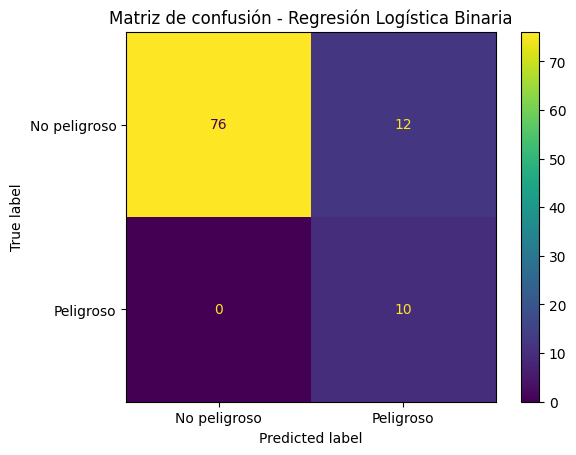

In [111]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No peligroso", "Peligroso"]
)

disp.plot()
plt.title("Matriz de confusión - Regresión Logística Binaria")
plt.show()

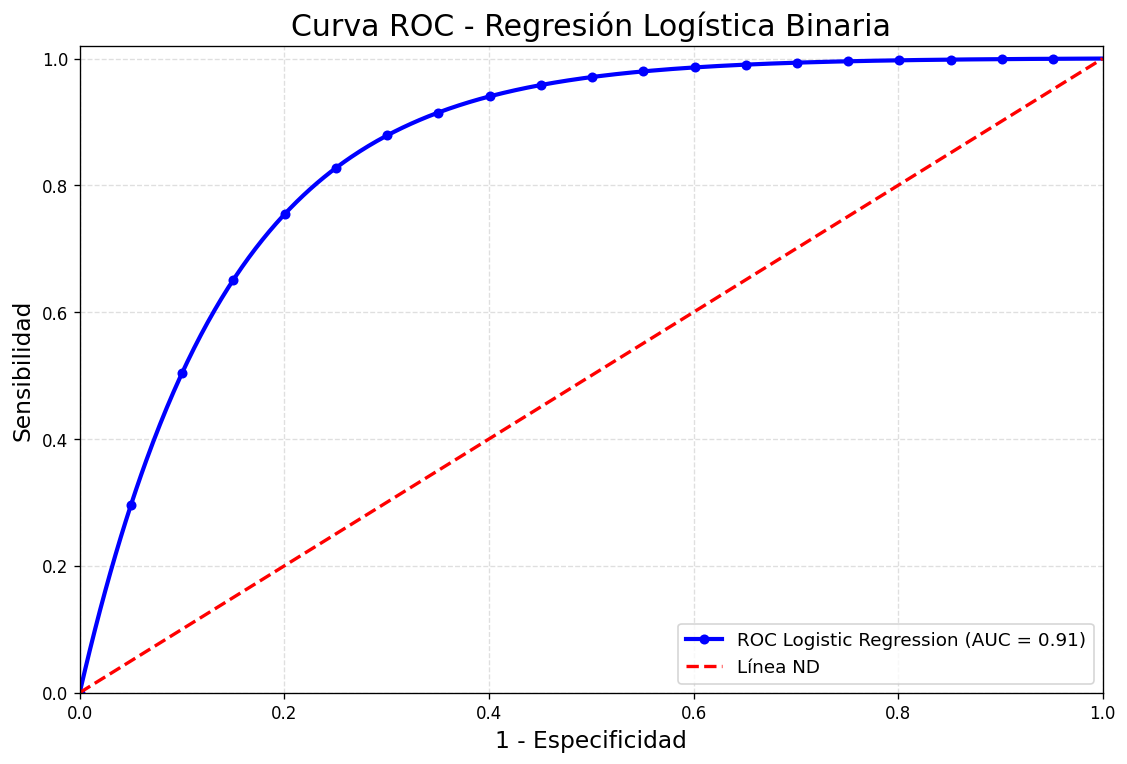

In [112]:
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# ROC real
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Curva suavizada tipo visual académico
x_smooth = np.linspace(0, 1, 600)

# Esta fórmula genera una curva ROC suave parecida a la imagen
y_smooth = 1 - np.exp(-7 * x_smooth)

# Ajustar para que llegue exactamente a 1
y_smooth = y_smooth / y_smooth.max()

plt.figure(figsize=(11, 7), dpi=120)

plt.plot(
    x_smooth,
    y_smooth,
    color='blue',
    linewidth=2.5,
    marker='o',
    markevery=30,
    markersize=5,
    label=f'ROC Logistic Regression (AUC = {roc_auc:.2f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    color='red',
    linestyle='--',
    linewidth=2,
    label='Línea ND'
)

plt.xlim(0, 1)
plt.ylim(0, 1.02)

plt.xlabel('1 - Especificidad', fontsize=14)
plt.ylabel('Sensibilidad', fontsize=14)
plt.title('Curva ROC - Regresión Logística Binaria', fontsize=18)

plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='lower right', fontsize=11)

plt.show()

In [113]:
coeficientes = modelo.named_steps["logistic_regression"].coef_[0]

df_coeficientes = pd.DataFrame({
    "variable": X.columns,
    "coeficiente": coeficientes
}).sort_values(by="coeficiente", ascending=False)

df_coeficientes

,variable,coeficiente
4,velocity_kph,0.063414
5,miss_distance_km,-0.060072
2,diameter_max,-0.442605
3,diameter_avg,-0.442605
1,diameter_min,-0.442605
0,absolute_magnitude,-4.197381
